# Intra-Node Analysis 

This notebook loads a benchmark's capability tree and measures each node's [internal consistency reliability](https://www.statisticshowto.com/internal-consistency/), or how well instances in the node produce similar model rankings.

We'll try three different approaches to measure each node's internal consistency reliability:

1. Split-halves Kendall's Tau
2. Bootstrapped Kendall's Tau
3. Mini-batch Kendall's W

## Set Up

Import packages.

In [10]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import kendalltau
from tqdm import tqdm
from src.utils.capability_tree import collect_nodes, get_node_indices, load_capability_tree
from src.utils.enums import Dataset
from src.utils.metrics import kendallw
from src.utils.model import load_model_scores
from src.utils.path import build_plot_path
from src.utils.plot import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Specify the benchmark to analyze, and load its dataset and model scores.

In [ ]:
dataset = Dataset.MMLU
model_scores_df = load_model_scores(dataset)
models = model_scores_df.columns.tolist()

root = load_capability_tree(dataset)
nodes = collect_nodes(root)
colors = sns.color_palette("tab10")

print(f"Number of instances: {(num_instances:=len(model_scores_df))}")
print(f"Number of models: {(num_models:=len(models))}")
print(f"Number of nodes (min 50 instances): {(num_nodes:=len(nodes))}")

Number of instances: 14042
Number of models: 9
Number of nodes (min 50 instances): 251


View the first few nodes in the capability tree.

In [ ]:
num_view = 5
for node in nodes[:num_view]:
    print(f"  [{node['size']} instances] {node['capability'][:80]}")

  [1247 instances] Developing quantitative reasoning and analytical problem-solving skills
  [223 instances] Enhancing statistical and probabilistic reasoning and analysis skills
  [76 instances] Analyzing and applying probabilistic and statistical reasoning and techniques
  [566 instances] Utilizing mathematical reasoning and problem-solving principles
  [296 instances] Analyzing and applying mathematical and algebraic principles and structures


## Analyses

### 1. Split-Halves Kendall's Tau

For each node, do the following:
1. Randomly split the node's instances into two mutually exclusive halves
2. Calculate the model rankings on Half A and Half B
3. Compute the Kendall's Tau between Half A and Half B
4. Repeat steps 1-3 for many iterations and average the Kendall's Taus across all iterations

In [13]:
num_trials = 500

kwargs = {
    "desc": "Computing split-half Kendall's Taus",
    "total": num_nodes,
    "unit": "nodes",
}

split_half_results = []

for node in tqdm(nodes, **kwargs):
    indices = get_node_indices(node)
    node_scores = model_scores_df.iloc[indices]
    node_size = len(node_scores)

    taus = []
    for trial in range(num_trials):
        rng = np.random.default_rng(trial)
        shuffled_indices = rng.permutation(node_size)
        half = node_size // 2
        scores_a = node_scores.iloc[shuffled_indices[:half]].mean()
        scores_b = node_scores.iloc[shuffled_indices[half:]].mean()
        tau, _ = kendalltau(scores_a, scores_b)
        taus.append(tau)

    split_half_results.append(
        {
            "node": node["capability"],
            "mean_kendall_tau": np.mean(taus),
            "std_kendall_tau": np.std(taus),
            "num_instances": node_size,
        }
    )

split_half_df = pd.DataFrame(split_half_results)
split_half_df.head()

Computing split-half Kendall's Taus: 100%|██████████| 251/251 [01:43<00:00,  2.43nodes/s]


,node,mean_kendall_tau,std_kendall_tau,num_instances
0,Developing quantitative reasoning and analytic...,0.688977,0.073614,1247
1,Enhancing statistical and probabilistic reason...,0.670825,0.113559,223
2,Analyzing and applying probabilistic and stati...,0.588474,0.126179,76
3,Utilizing mathematical reasoning and problem-s...,0.693830,0.086243,566
4,Analyzing and applying mathematical and algebr...,0.648840,0.102644,296


Plot a histogram showing the distribution of split-half Kendall's Taus across nodes.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\intra_node_analysis\MMLU\split_halves-kendall_tau-histogram.png


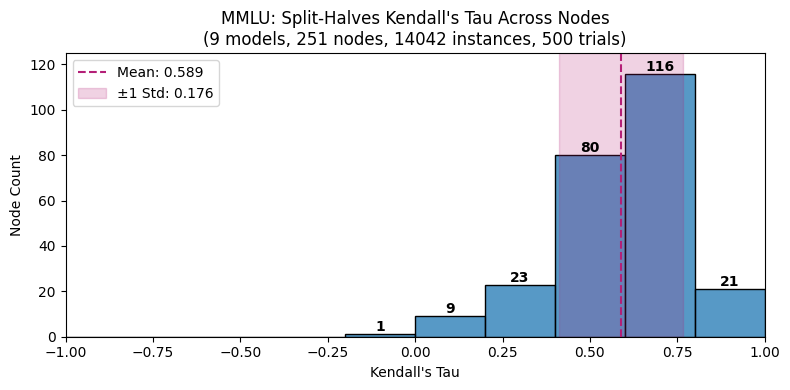

In [ ]:
xlim = {
    Dataset.CHATBOT_ARENA: (-1, 1),
    Dataset.CHATBOT_ARENA_NEW: (-1, 1),
    Dataset.DS_1000: (-1, 1),
    Dataset.MATH: (-1, 1),
    Dataset.MMLU: (-1, 1),
    Dataset.WILDCHAT_10K: (-1, 1),
}[dataset]

ylim = {
    Dataset.CHATBOT_ARENA: (0, num_nodes),
    Dataset.CHATBOT_ARENA_NEW: (0, num_nodes),
    Dataset.DS_1000: (0, num_nodes),
    Dataset.MATH: (0, num_nodes),
    Dataset.MMLU: (0, num_nodes // 2),
    Dataset.WILDCHAT_10K: (0, num_nodes),
}[dataset]

plot_histogram(
    split_half_df["mean_kendall_tau"],
    xlabel="Kendall's Tau",
    ylabel="Node Count",
    title=(
        f"{dataset}: Split-Halves Kendall's Tau Across Nodes"
        f"\n({num_models} models, {num_nodes} nodes, {num_instances} instances, {num_trials} trials)"
    ),
    annotate=True,
    mean=split_half_df["mean_kendall_tau"].mean(),
    std=split_half_df["mean_kendall_tau"].std(),
    xlim=xlim,
    ylim=ylim,
    color=colors[0],
)

analysis = "intra_node_analysis"
plot_name = "split-halves_kendall-tau_histogram"
file_path = build_plot_path(dataset, analysis, plot_name=plot_name)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()

### 2. Bootstrapped Kendall's Tau

For each node, do the following:
1. Compute the model ranking across all instances. We'll use this as our reference model ranking 
2. Create $B$ bootstrapped samples
3. Compute the Kendall's Tau between each bootstrapped sample's model ranking and the reference model ranking
4. Repeat steps 1-3 for $B$ iterations and average the Kendall's Taus

**NOTE:** Boostrapping *may* produce Kendall's Taus that are biased upward. See [here](https://stats.stackexchange.com/questions/88980/why-on-average-does-each-bootstrap-sample-contain-roughly-two-thirds-of-observat) for an explanation.

In [15]:
kwargs = {
    "desc": "Computing bootstrapped Kendall's Taus",
    "total": num_nodes,
    "unit": "nodes",
}

bootstrap_results = []

for node in tqdm(nodes, **kwargs):
    indices = get_node_indices(node)
    node_scores = model_scores_df.iloc[indices]
    n = len(node_scores)

    # Reference ranking: model ranking across all instances in the node
    reference_scores = node_scores.mean()

    taus = []
    for b in range(num_trials):
        rng = np.random.default_rng(b)
        bootstrap_indices = rng.integers(0, n, size=n)
        bootstrap_scores = node_scores.iloc[bootstrap_indices].mean()
        tau, _ = kendalltau(reference_scores, bootstrap_scores)
        taus.append(tau)

    bootstrap_results.append(
        {
            "node": node["capability"],
            "mean_kendall_tau": np.mean(taus),
            "std_kendall_tau": np.std(taus),
            "num_instances": n,
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df.head()

Computing bootstrapped Kendall's Taus: 100%|██████████| 251/251 [01:16<00:00,  3.29nodes/s]


,node,mean_kendall_tau,std_kendall_tau,num_instances
0,Developing quantitative reasoning and analytic...,0.848317,0.085185,1247
1,Enhancing statistical and probabilistic reason...,0.833307,0.089920,223
2,Analyzing and applying probabilistic and stati...,0.809743,0.103739,76
3,Utilizing mathematical reasoning and problem-s...,0.850725,0.087750,566
4,Analyzing and applying mathematical and algebr...,0.827005,0.090324,296


Plot a histogram showing the distribution of bootstrapped Kendall's Taus across nodes.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\intra_node_analysis\MMLU\bootstrap-kendall_tau-histogram.png


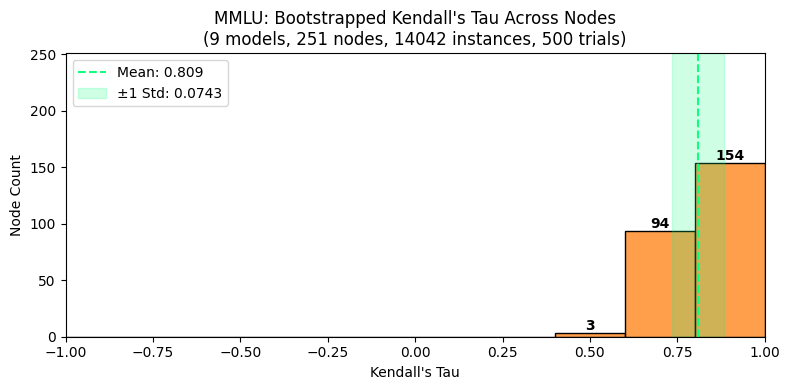

In [ ]:
xlim = {
    Dataset.CHATBOT_ARENA: (-1, 1),
    Dataset.CHATBOT_ARENA_NEW: (-1, 1),
    Dataset.DS_1000: (-1, 1),
    Dataset.MATH: (-1, 1),
    Dataset.MMLU: (-1, 1),
    Dataset.WILDCHAT_10K: (-1, 1),
}[dataset]

ylim = {
    Dataset.CHATBOT_ARENA: (0, num_nodes),
    Dataset.CHATBOT_ARENA_NEW: (0, num_nodes),
    Dataset.DS_1000: (0, num_nodes),
    Dataset.MATH: (0, num_nodes),
    Dataset.MMLU: (0, num_nodes),
    Dataset.WILDCHAT_10K: (0, num_nodes),
}[dataset]

plot_histogram(
    bootstrap_df["mean_kendall_tau"],
    xlabel="Kendall's Tau",
    ylabel="Node Count",
    title=(
        f"{dataset}: Bootstrapped Kendall's Tau Across Nodes"
        f"\n({num_models} models, {num_nodes} nodes, {num_instances} instances, {num_trials} trials)"
    ),
    annotate=True,
    mean=bootstrap_df["mean_kendall_tau"].mean(),
    std=bootstrap_df["mean_kendall_tau"].std(),
    xlim=xlim,
    ylim=ylim,
    color=colors[1],
)

analysis = "intra_node_analysis"
plot_name = "bootstrap_kendall-tau_histogram"
file_path = build_plot_path(dataset, analysis, plot_name=plot_name)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()

### 3. Mini-Batch Kendall's W

For each node, do the following:
1. Split the node's instances into $K$ random folds
2. Compute each fold's model rankings 
3. Compute Kendall's $W$ across all $K$ folds
4. Repeat steps 1-3 for many iterations and average the Kendall's $W$ values

In [17]:
num_folds = 5

kwargs = {
    "desc": "Computing mini-batch Kendall's W",
    "total": num_nodes,
    "unit": "nodes",
}

minibatch_w_results = []

for node in tqdm(nodes, **kwargs):
    indices = get_node_indices(node)
    node_scores = model_scores_df.iloc[indices]
    node_size = len(node_scores)

    kendallw_values = []
    for trial in range(num_trials):
        rng = np.random.default_rng(trial)
        shuffled_indices = rng.permutation(node_size)
        folds = np.array_split(shuffled_indices, num_folds)

        # Each row is one fold's mean model scores: shape (num_folds, num_models)
        fold_scores = np.array([node_scores.iloc[fold].mean().values for fold in folds])

        kendallw_values.append(kendallw(fold_scores))

    minibatch_w_results.append(
        {
            "node": node["capability"],
            "mean_kendallw": np.mean(kendallw_values),
            "std_kendallw": np.std(kendallw_values),
            "num_instances": node_size,
        }
    )

minibatch_w_df = pd.DataFrame(minibatch_w_results)
minibatch_w_df.head()

Computing mini-batch Kendall's W: 100%|██████████| 251/251 [03:35<00:00,  1.16nodes/s]


,node,mean_kendallw,std_kendallw,num_instances
0,Developing quantitative reasoning and analytic...,0.851062,0.030215,1247
1,Enhancing statistical and probabilistic reason...,0.769059,0.036303,223
2,Analyzing and applying probabilistic and stati...,0.644060,0.064793,76
3,Utilizing mathematical reasoning and problem-s...,0.832076,0.030268,566
4,Analyzing and applying mathematical and algebr...,0.793120,0.027924,296


Plot a histogram showing the distribution of mini-batch Kendall's $W$ values across nodes.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\intra_node_analysis\MMLU\mini-batch-kendall_w-histogram.png


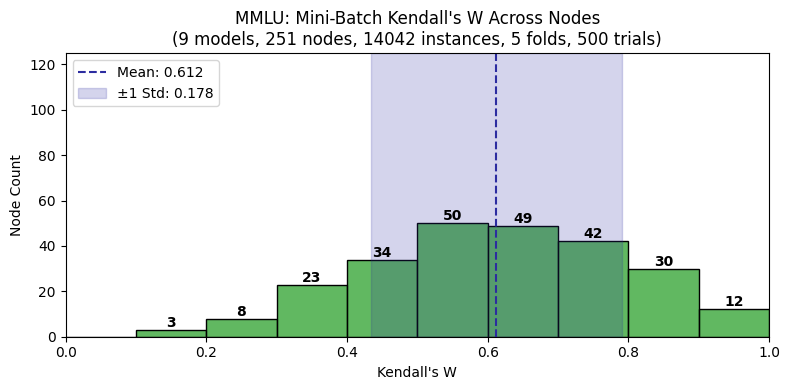

In [ ]:
xlim = {
    Dataset.CHATBOT_ARENA: (0, 1),
    Dataset.CHATBOT_ARENA_NEW: (0, 1),
    Dataset.DS_1000: (0, 1),
    Dataset.MATH: (0, 1),
    Dataset.MMLU: (0, 1),
    Dataset.WILDCHAT_10K: (0, 1),
}[dataset]

ylim = {
    Dataset.CHATBOT_ARENA: (0, num_nodes),
    Dataset.CHATBOT_ARENA_NEW: (0, num_nodes),
    Dataset.DS_1000: (0, num_nodes),
    Dataset.MATH: (0, num_nodes),
    Dataset.MMLU: (0, num_nodes // 2),
    Dataset.WILDCHAT_10K: (0, num_nodes),
}[dataset]

plot_histogram(
    minibatch_w_df["mean_kendallw"],
    xlabel="Kendall's W",
    ylabel="Node Count",
    title=(
        f"{dataset}: Mini-Batch Kendall's W Across Nodes"
        f"\n({num_models} models, {num_nodes} nodes, {num_instances} instances, {num_folds} folds, {num_trials} trials)"
    ),
    annotate=True,
    mean=minibatch_w_df["mean_kendallw"].mean(),
    std=minibatch_w_df["mean_kendallw"].std(),
    xlim=xlim,
    ylim=ylim,
    color=colors[2],
)

analysis = "intra_node_analysis"
plot_name = "mini-batch_kendall-w_histogram"
file_path = build_plot_path(dataset, analysis, plot_name=plot_name)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()